# Circuit compression
Simulating the dynamics of quantum systems is a prime candidate for quantum advantage, yet accurate Trotterizations are typically very deep, making them out of reach in the NISQ era and very expensive to run even for fully fault-tolerant devices.

On the other hand, variational circuits are a promising alternative: by performing some optimization, it's possible to approximate to high accuracy a deep (and accurate) Trotterization with a much shallower variational circuit. This is an example notebook for the compression algorithm introduced in [[1]](https://arxiv.org/abs/2507.01883). In general, this task of unitary compression involves the Hilbert-Schmidt cost between a target unitary $U$ and a parametrized ansatz $V(\vec\theta)$ $$C_\mathrm{HST}(U, V(\vec\theta)) = 1 - \frac{|\mathrm{Tr(U^\dagger V(\vec\theta))}|^2}{4^n},$$ which is $0$ iff. $U=V(\vec\theta)$ and $>0$ otherwise. 

Concretely, the goal of this notebook is to compress the dynamics $U$ of $L_U$ layers of a Heisenberg-like Hamiltonian into an ansatz $V(\vec\theta)$ with $L_V$ layers ($L_V < L_U$) by minimizing a local cost function
$$ R_{\mathcal{Q}_{LS}}^{\mathrm{loc}}(\vec \theta)= \frac{1}{2} - \frac{1}{6n} \sum_{j=1}^{n_q}\sum_{P = X, Y, Z} \langle\langle P_j \vert \boldsymbol{V(\vec\theta)U^\dagger}\vert P_j\rangle \rangle, $$
using Pauli propagation. The local cost function provides an upper bound on the HST cost $$C_\mathrm{HST}(U, V(\vec\theta)) \leq 2n R_{\mathcal{Q}_{LS}}^{\mathrm{loc}}(\vec \theta)$$

Once the compression is performed, we show using a statevector simulator (since we are implementing this for a small system) that applying the compressed ansatz $V(\vec\theta^\star)$ multiple times yields accurate dynamics, surpassing the accuracy of Trotterizations at both the same and larger depths.

In [ ]:
using PauliPropagation
using ForwardDiff
using Base.Threads
using Optim

### Setup
Create the 1D topology on `nq` qubits

In [3]:
nq = 10
topology = bricklayertopology(nq);

Specify the number of layers in the target $L_U$, of the ansatz $L_V$ and set the total evolution time that we want to compress.

In [4]:
LU = 8
LV = 2

t = 0.3;

Implement a single layer of a second order trotterization for the Heisenberg model Hamiltonian $$ e^{-i \Delta t H} \approx e^{-i \Delta t H_{YY}/2} e^{-i \Delta t H_{XX}/2} e^{-i \Delta t H_{ZZ}} e^{-i \Delta t H_{YY}/2} e^{-i \Delta t H_{XX}/2}$$
Note that `PauliRotation(theta)` gates implement rotations `exp(theta/2 P)`, so we need to multiply all our angles by a factor two.

In [5]:
function second_order_trotter(topology, n_layers, Jx, Jy, Jz, dt)
    circ = PauliRotation[]
    thetas = Float64[]

    for k = 1:n_layers
        if k == 1
            rxxlayer!(circ, topology)
            append!(thetas, ones(length(topology)) .* (dt * Jx))
            ryylayer!(circ, topology)
            append!(thetas, ones(length(topology)) .* (dt * Jy))
        end

        rzzlayer!(circ, topology)
        append!(thetas, ones(length(topology)) .* (2 * dt * Jz))

        if k < n_layers
            rxxlayer!(circ, topology)
            append!(thetas, ones(length(topology)) .* (2 * dt * Jx))
            ryylayer!(circ, topology)
            append!(thetas, ones(length(topology)) .* (2 * dt * Jy))
        else
            rxxlayer!(circ, topology)
            append!(thetas, ones(length(topology)) .* (dt * Jx))
            ryylayer!(circ, topology)
            append!(thetas, ones(length(topology)) .* (dt * Jy))
        end
    end

    return circ, thetas
end

second_order_trotter (generic function with 1 method)

Build the target and ansatz circuits

In [6]:
Jz = 1.
Jx = 0.5
Jy = 0.1

dt_U = t / LU 
dt_V = t /LV 

target_circuit, target_parameters = second_order_trotter(topology, LU, Jx, Jy, Jz, dt_U)
ansatz_circuit, ansatz_parameters_trotter = second_order_trotter(topology, LV, Jx, Jy, Jz, dt_V)

# needed later for the statevector simulator
comparison_deeper, thetas_deeper = second_order_trotter(topology, 2 * LV, Jx, Jy, Jz, dt_V / 2);

Specify PP truncations.

In [7]:
min_abs_coeff_target = 1.e-8
min_abs_coeff_ansatz = 1.e-9
W = 8;

Create a list `single_site_strings` containing all $3n_q$ Pauli strings that we need to compute the cost function

In [8]:
single_site_strings = [(PauliString(nq, :X, ii) for ii in 1:nq)..., (PauliString(nq, :Y, ii) for ii in 1:nq)..., (PauliString(nq, :Z, ii) for ii in 1:nq)...];

### Precompute targets
Compute $\bm{U^\dagger}\vert P_j\rangle\rangle = U^\dagger P_j U$ for all strings in `single_site_strings`

In [9]:
evolved_target_strings = Vector{PauliSum}(undef, length(single_site_strings))
@threads for i in eachindex(single_site_strings)
    s = single_site_strings[i]
    evolved_target_strings[i] = propagate(target_circuit, s, target_parameters; min_abs_coeff=min_abs_coeff_target, max_weight = W)
end

### Build local cost function
Compute $\langle \langle P_j\vert \boldsymbol{V(\vec\theta)}$ and then evaluate the inner product $\langle \langle P_j\vert \boldsymbol{V(\vec\theta)} \cdot \boldsymbol{U^\dagger}\vert P_j\rangle\rangle$.
Since we are interested in optimizing over $\vec\theta$, we need to extract the gradient as well. To this end we emply the `ForwardDiff` AD library.

In [10]:
function wrap_pauli_string(pstr, CT)
    return PauliString(pstr.nqubits, pstr.term, CT(1))
end

function Cloc(ansatz_params::Vector{CT}, ansatz_circ, single_site_strings, evolved_target_strings, min_abs_coeff, max_weight) where {CT}
    contribs = Vector{CT}(undef, length(single_site_strings))
    @threads for i in eachindex(single_site_strings)
        evolved = propagate(ansatz_circ, wrap_pauli_string(single_site_strings[i], CT),
                            ansatz_params; min_abs_coeff, max_weight)
        contribs[i] = scalarproduct(evolved_target_strings[i], evolved)
    end
    return 0.5 - sum(contribs) / (6 * nq)
end


lossfunction = θ -> Cloc(θ, ansatz_circuit, single_site_strings, evolved_target_strings, min_abs_coeff_ansatz, W)
g! = (g, θ) -> ForwardDiff.gradient!(g, lossfunction, θ);

Perform the optimization starting from the initial guess `ansatz_parameters_trotter` corresponding to the Trotter angles for $L_V$ layers.

In [11]:
gradtol = 1.e-5
maxiter = 20
optimizer = Optim.LBFGS()

res = Optim.optimize(lossfunction, g!, ansatz_parameters_trotter, optimizer,
    Optim.Options(show_trace=true, show_every=2, store_trace=true,
        g_tol=gradtol, iterations=maxiter))

thetas_optimized = res.minimizer;

Iter     Function value   Gradient norm 
     0     1.603985e-05     2.843205e-04
 * time: 0.022567033767700195
     2     1.165579e-05     5.394587e-05
 * time: 7.92047905921936
     4     8.504315e-06     2.046829e-04
 * time: 13.588085174560547
     6     5.170889e-06     4.151421e-05
 * time: 18.637370109558105
     8     5.032348e-06     6.685522e-06
 * time: 22.85816502571106


## Statevector simulator
We use the Yao library to simulate the dynamics of an initial state $\ket{\psi_0}$ under the differernt circuits. Note that the following results showing that the expectation value is much more accurate with the compressed ansatz can be strongly problem dependent, and must be taken as illustrative examples only.

In [12]:
using Yao
using LinearAlgebra

function heisenberg_1d(n, topology; J=1.0)
    terms = map(1:length(topology)) do k
    (i, j) = topology[k]
        Jx * (kron(n, i=>X, j=>X)) +
        Jy * (kron(n, i=>Y, j=>Y)) +
        Jz * (kron(n, i=>Z, j=>Z))
    end
    sum(terms)
end

heisenberg_1d (generic function with 1 method)

Create Hamiltonian as matrix, take matrix exponential

In [13]:
H = heisenberg_1d(nq, topology; J=1.0)

# 10 qubits
reg = product_state(bit"0101010101")

exact_finer_by = 10

psi = statevec(reg)

Hmat = Matrix(mat(H))
U_exact = exp(-im * (t/exact_finer_by) * Hmat);

Specify timesteps, and compute exact magnetization at those instants

In [14]:
n_reps = 20

magnetizations = zeros(nq, (n_reps*exact_finer_by)+1)
for j =1:nq
    Zstring = put(nq, j=>Z)
    magnetizations[j, 1] = real(expect(Zstring, arrayreg(psi)))
end

for k=1:(exact_finer_by * n_reps)
    psi = U_exact * psi
    reg_t = arrayreg(psi)  
    for j =1:nq
        Zstring = put(nq, j=>Z)
        magnetizations[j, k+1] = real(expect(Zstring, reg_t))
    end
end

In [15]:
# helpers for make PauliRotations into Yao

function elem_to_yao!(circuit, gate, theta)
    if gate.symbols == [:X, :X]
        push!(circuit, cnot(gate.qinds[2], gate.qinds[1]))
        push!(circuit, Yao.put(gate.qinds[2] => Yao.Rx(theta)))
        push!(circuit, cnot(gate.qinds[2], gate.qinds[1]))
    elseif gate.symbols == [:Y, :Y]
        push!(circuit, Yao.put(gate.qinds[1] => Yao.Rz(-pi / 2)))
        push!(circuit, Yao.put(gate.qinds[2] => Yao.Rz(-pi / 2)))
        push!(circuit, cnot(gate.qinds[2], gate.qinds[1]))
        push!(circuit, Yao.put(gate.qinds[2] => Yao.Rx(theta)))
        push!(circuit, cnot(gate.qinds[2], gate.qinds[1]))
        push!(circuit, Yao.put(gate.qinds[1] => Yao.Rz(pi / 2)))
        push!(circuit, Yao.put(gate.qinds[2] => Yao.Rz(pi / 2)))
    elseif gate.symbols == [:Z, :Z]
        push!(circuit, cnot(gate.qinds[1], gate.qinds[2]))
        push!(circuit, Yao.put(gate.qinds[2] => Yao.Rz(theta)))
        push!(circuit, cnot(gate.qinds[1], gate.qinds[2]))
    end
end

function make_yao_circ(pp_circ, pp_thetas, nq)
    yao_circ = chain(nq)

    for (gate, theta) in zip(pp_circ, pp_thetas)
        elem_to_yao!(yao_circ, gate, theta)
    end
    return yao_circ
end

make_yao_circ (generic function with 1 method)

Create Yao circuits

In [16]:
ansatz_trotter = make_yao_circ(ansatz_circuit, ansatz_parameters_trotter, nq)
ansatz_optimized = make_yao_circ(ansatz_circuit, thetas_optimized, nq)
deeper_trotter = make_yao_circ(comparison_deeper, thetas_deeper, nq);

Run statevector simulations for different trotterizations

In [17]:
state_prep = chain(nq)
for i=1:2:nq
    push!(state_prep, put(nq, i=>X))
end

psi_AT  = Yao.apply!(Yao.zero_state(nq), state_prep)
psi_opt  = Yao.apply!(Yao.zero_state(nq), state_prep)
psi_deeper = Yao.apply!(Yao.zero_state(nq), state_prep)

magnetizations_AT = zeros(nq, n_reps+1)
magnetizations_opt = zeros(nq, n_reps+1)
magnetizations_deeper = zeros(nq, n_reps+1)
for j =1:nq
    Zstring = put(nq, j=>Z)
    magnetizations_AT[j, 1] = real(expect(Zstring, psi_AT))
    magnetizations_opt[j, 1] = real(expect(Zstring, psi_opt))
    magnetizations_deeper[j, 1] = real(expect(Zstring, psi_deeper))
end

for k=1:n_reps
    psi_AT = Yao.apply!(psi_AT, ansatz_trotter) 
    psi_opt = Yao.apply!(psi_opt, ansatz_optimized) 
    psi_deeper = Yao.apply!(psi_deeper, deeper_trotter) 
    for j =1:nq
        Zstring = put(nq, j=>Z)
        magnetizations_AT[j, k+1] = real(expect(Zstring, psi_AT))
        magnetizations_opt[j, k+1] = real(expect(Zstring, psi_opt))
        magnetizations_deeper[j, k+1] = real(expect(Zstring, psi_deeper))
    end
end

Plot example magnetization at site 3 and plot mean error over all magnetizations at different times

3, mean AT = 0.011479990614442506, mean deeper = 0.0029282449743589537, mean OPT = 0.002245684907042453


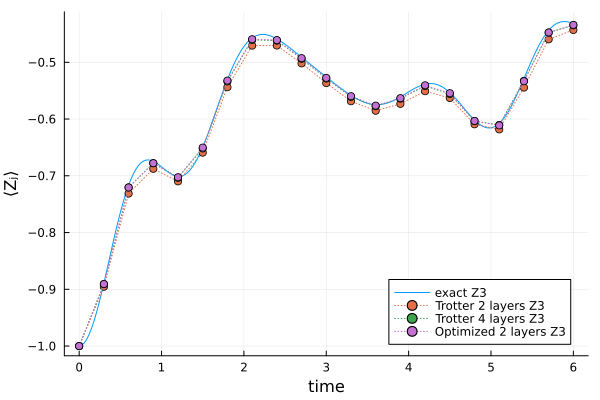

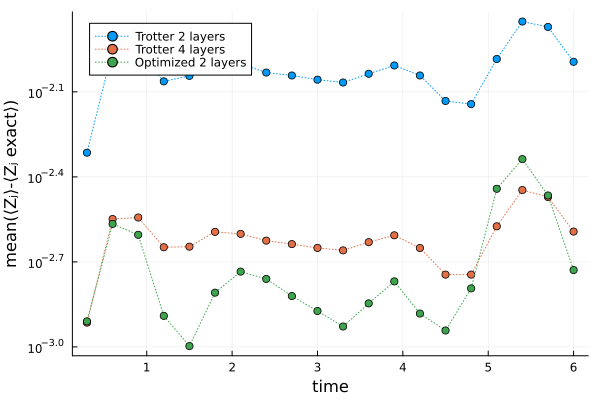

In [18]:
using Plots 
using Statistics

p = Plots.plot(xlabel="time", ylabel="⟨Zⱼ⟩", leg=:bottomright)
p_err = Plots.plot(xlabel="time", ylabel="mean(⟨Zⱼ⟩-⟨Zⱼ exact⟩)", yscale=:log10)

timestamps = collect(range(0., n_reps * t, length=n_reps+1))
timestamps_exact = collect(range(0., n_reps * t, length=((n_reps * exact_finer_by)+1)))

for j in [3]
    Plots.plot!(p, timestamps_exact, magnetizations[j, :], label = "exact Z$j")
    Plots.plot!(p, timestamps, magnetizations_AT[j, :], label = "Trotter $(LV) layers Z$j", markershape=:circle, linestyle=:dot)
    Plots.plot!(p, timestamps, magnetizations_deeper[j, :], label = "Trotter $(2*LV) layers Z$j", markershape=:circle, linestyle=:dot)
    Plots.plot!(p, timestamps, magnetizations_opt[j, :], label = "Optimized $(LV) layers Z$j", markershape=:circle, linestyle=:dot)
    println("$j, mean AT = $(mean(abs.(magnetizations[j, (1+exact_finer_by):exact_finer_by:end] .- magnetizations_AT[j, 2:end]))), mean deeper = $(mean(abs.(magnetizations[j, (1+exact_finer_by):exact_finer_by:end] .- magnetizations_deeper[j, 2:end]))), mean OPT = $(mean(abs.(magnetizations[j, (1+exact_finer_by):exact_finer_by:end] .- magnetizations_opt[j, 2:end])))")
end

Plots.plot!(p_err, timestamps[2:end], transpose(mean(abs.(magnetizations[:, (1+exact_finer_by):exact_finer_by:end] .- magnetizations_AT[:, 2:end]), dims=1)), label = "Trotter $(LV) layers", markershape=:circle, linestyle=:dot)
Plots.plot!(p_err, timestamps[2:end], transpose(mean(abs.(magnetizations[:, (1+exact_finer_by):exact_finer_by:end] .- magnetizations_deeper[:, 2:end]), dims=1)), label = "Trotter $(2*LV) layers", markershape=:circle, linestyle=:dot)
Plots.plot!(p_err, timestamps[2:end], transpose(mean(abs.(magnetizations[:, (1+exact_finer_by):exact_finer_by:end] .- magnetizations_opt[:, 2:end]), dims=1)), label = "Optimized $(LV) layers", markershape=:circle, linestyle=:dot)


display(p)
display(p_err)